In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Load dataset

In [2]:
data=pd.read_csv("C:/Users/DELL/Desktop/FBS/Data analysis/Demos/Datasets-20260831T171242Z-1-001/Datasets/cars93.csv")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    93 non-null     str    
 1   Model           93 non-null     str    
 2   Type            93 non-null     str    
 3   Price           93 non-null     float64
 4   MPG.city        93 non-null     int64  
 5   AirBags         79 non-null     str    
 6   Horsepower      93 non-null     int64  
 7   Passengers      93 non-null     int64  
 8   Rear.seat.room  91 non-null     float64
 9   Luggage.room    82 non-null     float64
dtypes: float64(3), int64(3), str(4)
memory usage: 7.4 KB


In [4]:
data.describe()

,Price,MPG.city,Horsepower,Passengers,Rear.seat.room,Luggage.room
count,93.000000,93.000000,93.000000,93.000000,91.000000,82.000000
mean,19.509677,22.365591,143.827957,5.086022,27.829670,13.890244
std,9.659430,5.619812,52.374410,1.038979,2.989072,2.997967
min,7.400000,15.000000,55.000000,2.000000,19.000000,6.000000
25%,12.200000,18.000000,103.000000,4.000000,26.000000,12.000000
50%,17.700000,21.000000,140.000000,5.000000,27.500000,14.000000
75%,23.300000,25.000000,170.000000,6.000000,30.000000,15.000000
max,61.900000,46.000000,300.000000,8.000000,36.000000,22.000000


#### format
1. string- Manufacturer,Model,Type,AirBags(4 string columns)
2. int-MPG.city, Horsepower, Passengers(3 int columns)
3. float-Price, Rear.seat.room, Luggage.room(3 float columns)

##### Total columns-10
##### Total rows-93(0-92)

In [5]:
data.isnull().sum()

Manufacturer       0
Model              0
Type               0
Price              0
MPG.city           0
AirBags           14
Horsepower         0
Passengers         0
Rear.seat.room     2
Luggage.room      11
dtype: int64

#### null values
1. airbag-14
2. Rear.seat.room-2
3. Luggage.room-11

In [6]:
data.head()

,Manufacturer,Model,Type,Price,MPG.city,AirBags,Horsepower,Passengers,Rear.seat.room,Luggage.room
0,Acura,Integra,Small,15.9,25,Driver only,140,5,26.5,11.0
1,Acura,Legend,Midsize,33.9,18,Driver & Passenger,200,5,30.0,15.0
2,Audi,90,Compact,29.1,20,Driver only,172,5,28.0,14.0
3,Audi,100,Midsize,37.7,19,Driver & Passenger,172,6,31.0,17.0
4,BMW,535i,Midsize,30.0,22,Driver only,208,4,27.0,13.0


In [7]:
data.describe(include="object")

C:\Users\DELL\AppData\Local\Temp\ipykernel_14888\460854327.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object")


,Manufacturer,Model,Type,AirBags
count,93,93,93,79
unique,32,93,6,2
top,Chevrolet,Integra,Midsize,Driver only
freq,8,1,22,57


In [8]:
data.duplicated().sum()

np.int64(0)

##### Duplicate record-0

In [9]:
data.tail()

,Manufacturer,Model,Type,Price,MPG.city,AirBags,Horsepower,Passengers,Rear.seat.room,Luggage.room
88,Volkswagen,Eurovan,Van,19.7,17,Driver & Passenger,109,7,34.0,NaN
89,Volkswagen,Passat,Compact,20.0,21,Driver & Passenger,134,5,31.5,14.0
90,Volkswagen,Corrado,Sporty,23.3,18,Driver & Passenger,178,4,26.0,15.0
91,Volvo,240,Compact,22.7,21,Driver only,114,5,29.5,14.0
92,Volvo,850,Midsize,26.7,20,Driver & Passenger,168,5,30.0,15.0


In [10]:
res=data.groupby(['Manufacturer'])
dict(list(res))

{('Acura',):   Manufacturer    Model     Type  Price  MPG.city             AirBags  \
 0        Acura  Integra    Small   15.9        25         Driver only   
 1        Acura   Legend  Midsize   33.9        18  Driver & Passenger   
 
    Horsepower  Passengers  Rear.seat.room  Luggage.room  
 0         140           5            26.5          11.0  
 1         200           5            30.0          15.0  ,
 ('Audi',):   Manufacturer Model     Type  Price  MPG.city             AirBags  \
 2         Audi    90  Compact   29.1        20         Driver only   
 3         Audi   100  Midsize   37.7        19  Driver & Passenger   
 
    Horsepower  Passengers  Rear.seat.room  Luggage.room  
 2         172           5            28.0          14.0  
 3         172           6            31.0          17.0  ,
 ('BMW',):   Manufacturer Model     Type  Price  MPG.city      AirBags  Horsepower  \
 4          BMW  535i  Midsize   30.0        22  Driver only         208   
 
    Passengers  Re

In [11]:
data['AirBags']=data['AirBags'].fillna(data['AirBags'].mode()[0],inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14888\162447423.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['AirBags']=data['AirBags'].fillna(data['AirBags'].mode()[0],inplace=True)


In [12]:
data.isnull().sum()

Manufacturer       0
Model              0
Type               0
Price              0
MPG.city           0
AirBags            0
Horsepower         0
Passengers         0
Rear.seat.room     2
Luggage.room      11
dtype: int64

In [13]:
data['Rear.seat.room']=data['Rear.seat.room'].fillna(data['Rear.seat.room'].mean())

In [14]:
data['Luggage.room']=data['Luggage.room'].fillna(data['Luggage.room'].mean())

In [15]:
data.isnull().sum()

Manufacturer      0
Model             0
Type              0
Price             0
MPG.city          0
AirBags           0
Horsepower        0
Passengers        0
Rear.seat.room    0
Luggage.room      0
dtype: int64

##### Airbags null value replace-mode
##### Rear.seat.room null values-mean
##### Luggage.room null values-mean

In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    93 non-null     str    
 1   Model           93 non-null     str    
 2   Type            93 non-null     str    
 3   Price           93 non-null     float64
 4   MPG.city        93 non-null     int64  
 5   AirBags         93 non-null     str    
 6   Horsepower      93 non-null     int64  
 7   Passengers      93 non-null     int64  
 8   Rear.seat.room  93 non-null     float64
 9   Luggage.room    93 non-null     float64
dtypes: float64(3), int64(3), str(4)
memory usage: 7.4 KB


## Univariate analysis

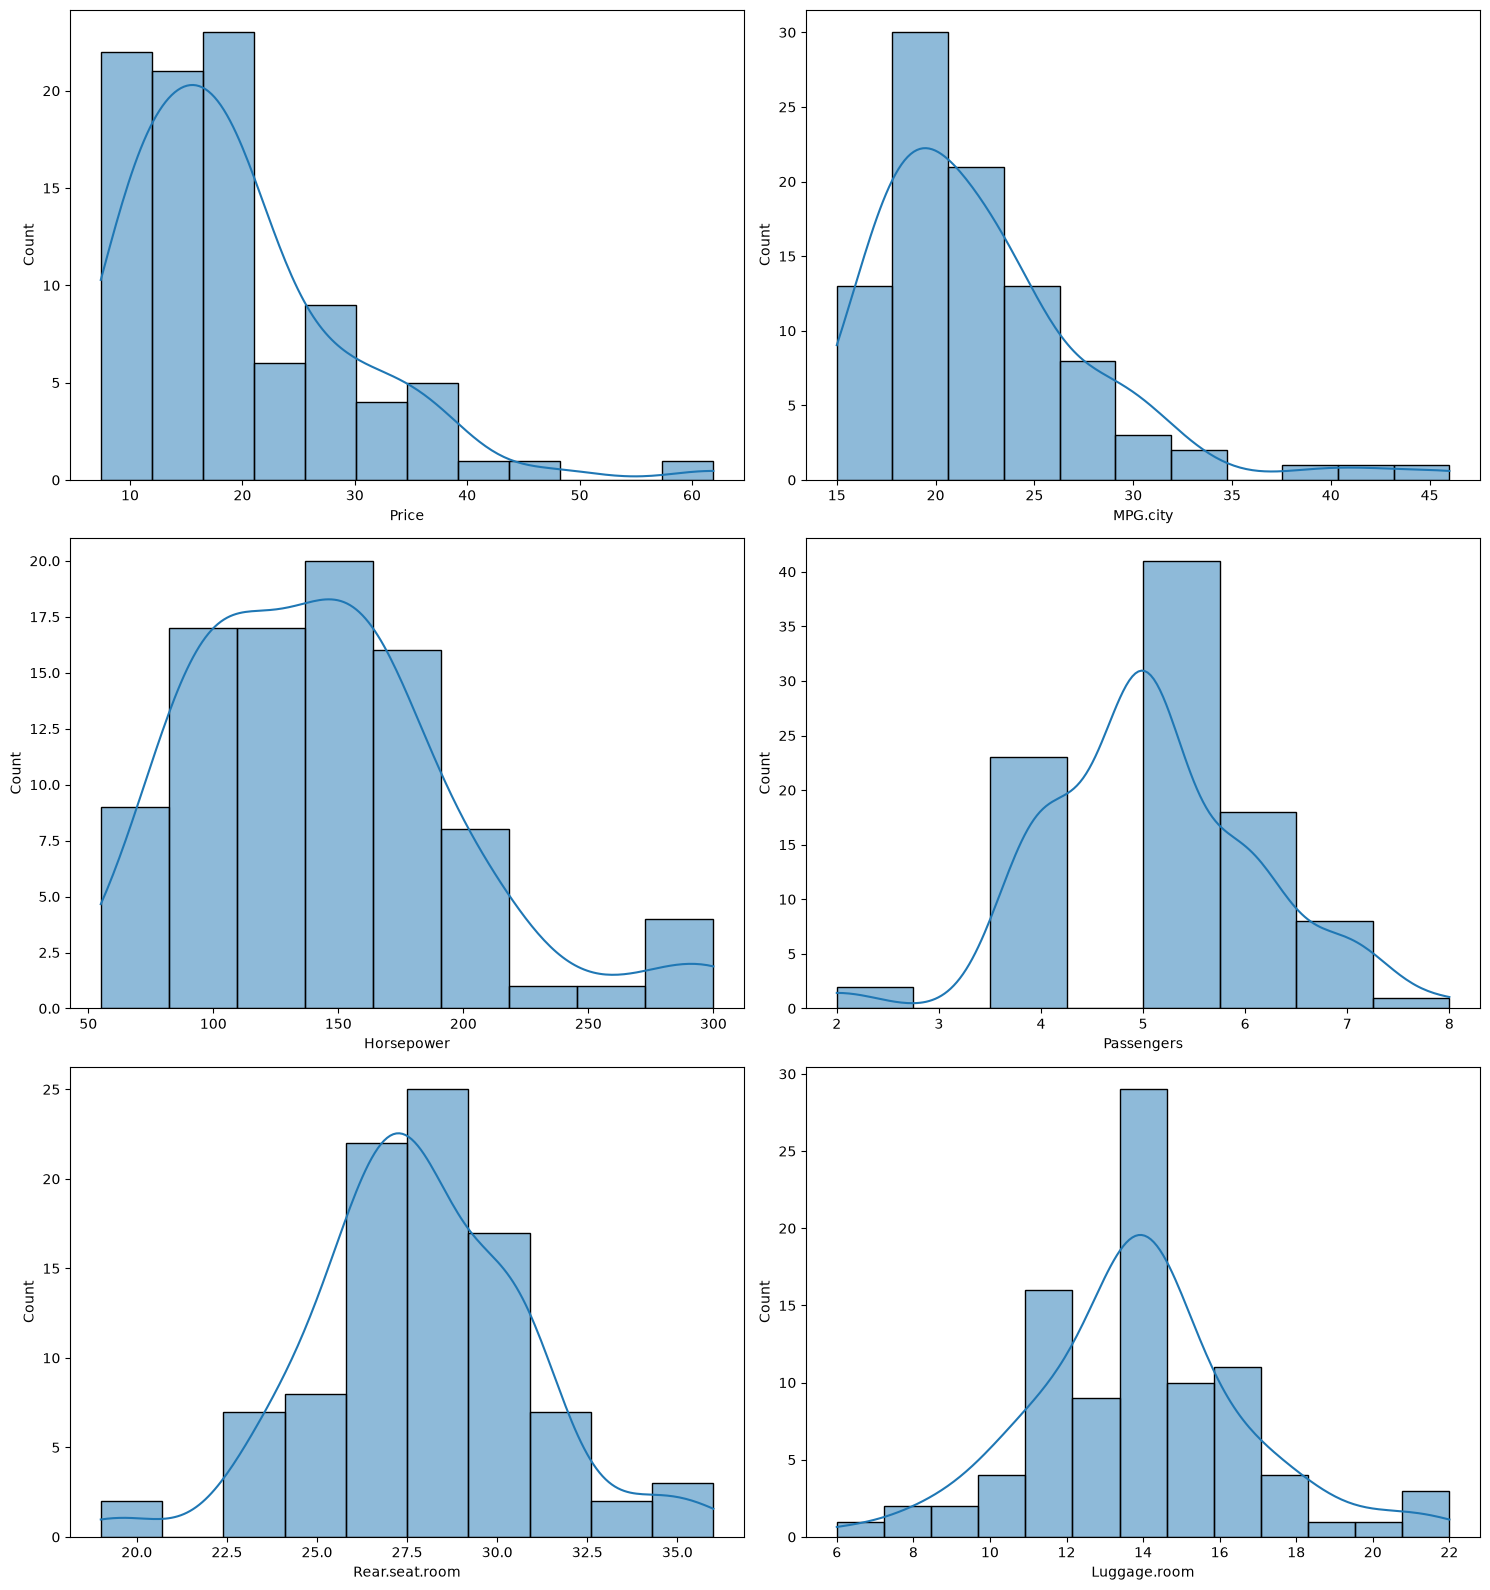

In [22]:
numerical_cols=['Price','MPG.city','Horsepower','Passengers','Rear.seat.room','Luggage.room']
fig,axes=plt.subplots(3,2,figsize=(15,16))
axes=axes.flatten()
for i,col in enumerate(numerical_cols):
    sns.histplot(data[col],kde=True,ax=axes[i])
plt.tight_layout()
plt.savefig('Univariate_EDA_Full.png',dpi=300,bbox_inches='tight')
plt.show()

## Bivariate analysis

In [18]:
data[numerical_cols].corr()

,Price,MPG.city,Horsepower,Passengers,Rear.seat.room,Luggage.room
Price,1.000000,-0.594562,0.788218,0.057860,0.301888,0.354635
MPG.city,-0.594562,1.000000,-0.672636,-0.416856,-0.380435,-0.462204
Horsepower,0.788218,-0.672636,1.000000,0.009264,0.236871,0.328568
Passengers,0.057860,-0.416856,0.009264,1.000000,0.622400,0.418210
Rear.seat.room,0.301888,-0.380435,0.236871,0.622400,1.000000,0.587923
Luggage.room,0.354635,-0.462204,0.328568,0.418210,0.587923,1.000000


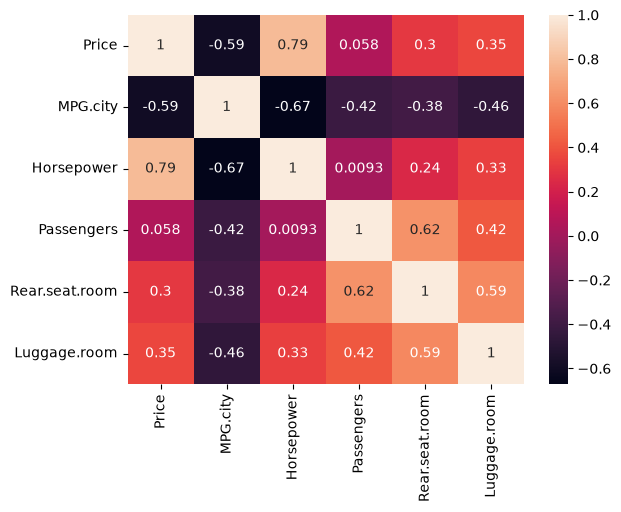

In [23]:
sns.heatmap(data[numerical_cols].corr(),annot=True)
plt.savefig('Bivariate_EDA_Full.png',dpi=300,bbox_inches='tight')

In [20]:
data.columns

Index(['Manufacturer', 'Model', 'Type', 'Price', 'MPG.city', 'AirBags',
       'Horsepower', 'Passengers', 'Rear.seat.room', 'Luggage.room'],
      dtype='str')

In [21]:
data['Manufacturer'].value_counts().head()

Manufacturer
Chevrolet    8
Ford         8
Dodge        6
Mazda        5
Pontiac      5
Name: count, dtype: int64